In [1]:
# ============================================
# UCF-Crime Abnormal Behaviour Detection
# Step 1: Check GPU and Dataset
# ============================================

import os
import torch

print("PyTorch version:", torch.__version__)

# Check GPU
if torch.cuda.is_available():
    print("GPU available:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not available.")

# Find the UCF-Crime dataset
DATASET_ROOT = "/kaggle/input/ucf-crime-dataset"

print("\nDataset path:")
print(DATASET_ROOT)

print("\nDataset exists:", os.path.exists(DATASET_ROOT))

# Show folders
if os.path.exists(DATASET_ROOT):
    print("\nFolders inside dataset:")
    for item in os.listdir(DATASET_ROOT):
        print(" -", item)

PyTorch version: 2.10.0+cu128
GPU available: Tesla T4

Dataset path:
/kaggle/input/ucf-crime-dataset

Dataset exists: False


In [2]:
import os

print("Folders inside /kaggle/input:\n")

for item in os.listdir("/kaggle/input"):
    print(item)

Folders inside /kaggle/input:

datasets


In [3]:
import os

root = "/kaggle/input/datasets"

print("Finding folders inside /kaggle/input/datasets...\n")

for current_path, folders, files in os.walk(root):
    level = current_path.replace(root, "").count(os.sep)

    # Show only the first few levels
    if level <= 2:
        print(current_path)
        for folder in folders:
            print("   📁", folder)

Finding folders inside /kaggle/input/datasets...

/kaggle/input/datasets
   📁 odins0n
/kaggle/input/datasets/odins0n
   📁 ucf-crime-dataset
/kaggle/input/datasets/odins0n/ucf-crime-dataset
   📁 Test
   📁 Train


KeyboardInterrupt: 

In [ ]:
import os

DATASET_ROOT = "/kaggle/input/datasets/odins0n/ucf-crime-dataset"

TRAIN_DIR = os.path.join(DATASET_ROOT, "Train")
TEST_DIR = os.path.join(DATASET_ROOT, "Test")

print("TRAIN PATH:", TRAIN_DIR)
print("TEST PATH :", TEST_DIR)

print("\nTrain classes:")
train_classes = sorted(os.listdir(TRAIN_DIR))
for i, name in enumerate(train_classes, 1):
    print(f"{i}. {name}")

print("\nTest classes:")
test_classes = sorted(os.listdir(TEST_DIR))
for i, name in enumerate(test_classes, 1):
    print(f"{i}. {name}")

In [4]:
# ============================================
# UCF-Crime Dataset Configuration
# ============================================

import os

DATASET_ROOT = "/kaggle/input/datasets/odins0n/ucf-crime-dataset"

TRAIN_DIR = os.path.join(DATASET_ROOT, "Train")
TEST_DIR = os.path.join(DATASET_ROOT, "Test")

# Normal class
NORMAL_CLASS = "NormalVideos"

# All abnormal classes
ABNORMAL_CLASSES = [
    "Abuse",
    "Arrest",
    "Arson",
    "Assault",
    "Burglary",
    "Explosion",
    "Fighting",
    "RoadAccidents",
    "Robbery",
    "Shooting",
    "Shoplifting",
    "Stealing",
    "Vandalism"
]

print("Dataset:", DATASET_ROOT)
print("Train directory exists:", os.path.exists(TRAIN_DIR))
print("Test directory exists:", os.path.exists(TEST_DIR))

print("\nNormal class:")
print(NORMAL_CLASS)

print("\nAbnormal classes:")
for name in ABNORMAL_CLASSES:
    print("-", name)

print("\nTotal classes:", 1 + len(ABNORMAL_CLASSES))

Dataset: /kaggle/input/datasets/odins0n/ucf-crime-dataset
Train directory exists: True
Test directory exists: True

Normal class:
NormalVideos

Abnormal classes:
- Abuse
- Arrest
- Arson
- Assault
- Burglary
- Explosion
- Fighting
- RoadAccidents
- Robbery
- Shooting
- Shoplifting
- Stealing
- Vandalism

Total classes: 14


In [5]:
# ============================================
# STEP 12: Create a Balanced Binary Dataset
# ============================================

import os
import random
from pathlib import Path

SEED = 42
random.seed(SEED)

# Number of images used from EACH class
TRAIN_PER_CLASS = 1000
TEST_PER_CLASS = 300

# Binary labels
NORMAL_LABEL = 0
ABNORMAL_LABEL = 1

def get_images_from_class(folder, limit, seed=42):
    """
    Get a reproducible subset of PNG images from one class.
    """
    files = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(".png")
    ]

    rng = random.Random(seed)
    rng.shuffle(files)

    return files[:min(limit, len(files))]


# --------------------------------------------
# Build training file list
# --------------------------------------------

train_samples = []

# Normal
normal_train_dir = os.path.join(TRAIN_DIR, NORMAL_CLASS)

normal_files = get_images_from_class(
    normal_train_dir,
    TRAIN_PER_CLASS,
    SEED
)

for path in normal_files:
    train_samples.append((path, NORMAL_LABEL))


# Abnormal
for class_index, class_name in enumerate(ABNORMAL_CLASSES):
    class_dir = os.path.join(TRAIN_DIR, class_name)

    files = get_images_from_class(
        class_dir,
        TRAIN_PER_CLASS,
        SEED + class_index + 1
    )

    for path in files:
        train_samples.append((path, ABNORMAL_LABEL))


# --------------------------------------------
# Build test file list
# --------------------------------------------

test_samples = []

# Normal test
normal_test_dir = os.path.join(TEST_DIR, NORMAL_CLASS)

normal_test_files = get_images_from_class(
    normal_test_dir,
    TEST_PER_CLASS,
    SEED
)

for path in normal_test_files:
    test_samples.append((path, NORMAL_LABEL))


# Abnormal test
for class_index, class_name in enumerate(ABNORMAL_CLASSES):
    class_dir = os.path.join(TEST_DIR, class_name)

    files = get_images_from_class(
        class_dir,
        TEST_PER_CLASS,
        SEED + class_index + 1
    )

    for path in files:
        test_samples.append((path, ABNORMAL_LABEL))


# Shuffle complete datasets
random.Random(SEED).shuffle(train_samples)
random.Random(SEED).shuffle(test_samples)


# --------------------------------------------
# Print dataset information
# --------------------------------------------

print("============================================")
print("BALANCED BINARY DATASET")
print("============================================")

print(f"Training images : {len(train_samples)}")
print(f"Testing images  : {len(test_samples)}")

print("\nTraining labels:")
print("Normal   :", sum(label == 0 for _, label in train_samples))
print("Abnormal :", sum(label == 1 for _, label in train_samples))

print("\nTesting labels:")
print("Normal   :", sum(label == 0 for _, label in test_samples))
print("Abnormal :", sum(label == 1 for _, label in test_samples))

print("\nRandom seed:", SEED)

BALANCED BINARY DATASET
Training images : 14000
Testing images  : 4197

Training labels:
Normal   : 1000
Abnormal : 13000

Testing labels:
Normal   : 300
Abnormal : 3897

Random seed: 42


In [6]:
# ============================================
# STEP 12B: MAKE THE DATASET TRULY BALANCED
# ============================================

import random

SEED = 42

TRAIN_PER_CLASS = 1000
TEST_PER_CLASS = 300

random.seed(SEED)

# Separate Normal and Abnormal samples
train_normal = [x for x in train_samples if x[1] == 0]
train_abnormal = [x for x in train_samples if x[1] == 1]

test_normal = [x for x in test_samples if x[1] == 0]
test_abnormal = [x for x in test_samples if x[1] == 1]

# Select equal numbers
train_normal = train_normal[:TRAIN_PER_CLASS]
train_abnormal = train_abnormal[:TRAIN_PER_CLASS]

test_normal = test_normal[:TEST_PER_CLASS]
test_abnormal = test_abnormal[:TEST_PER_CLASS]

# Combine
train_samples_balanced = train_normal + train_abnormal
test_samples_balanced = test_normal + test_abnormal

# Shuffle
random.Random(SEED).shuffle(train_samples_balanced)
random.Random(SEED).shuffle(test_samples_balanced)

print("============================================")
print("BALANCED BINARY DATASET")
print("============================================")

print("\nTraining:")
print("Normal   :", sum(y == 0 for _, y in train_samples_balanced))
print("Abnormal :", sum(y == 1 for _, y in train_samples_balanced))
print("Total    :", len(train_samples_balanced))

print("\nTesting:")
print("Normal   :", sum(y == 0 for _, y in test_samples_balanced))
print("Abnormal :", sum(y == 1 for _, y in test_samples_balanced))
print("Total    :", len(test_samples_balanced))

print("\nRandom seed:", SEED)

BALANCED BINARY DATASET

Training:
Normal   : 1000
Abnormal : 1000
Total    : 2000

Testing:
Normal   : 300
Abnormal : 300
Total    : 600

Random seed: 42


In [7]:
# ============================================
# STEP 13: CNN MODEL
# ============================================

import torch
import torch.nn as nn
from torchvision import models

# Use GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Load pretrained ResNet18
model = models.resnet18(weights="DEFAULT")

# Replace the final layer for binary classification
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 1)
)

model = model.to(device)

print("\nModel created successfully!")
print("Architecture: ResNet18")
print("Task: Normal vs Abnormal")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s] 



Model created successfully!
Architecture: ResNet18
Task: Normal vs Abnormal


In [8]:
# ============================================
# STEP 14: IMAGE DATALOADERS
# ============================================

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class UCFBinaryDataset(Dataset):

    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):

        image_path, label = self.samples[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


# Create datasets
train_dataset = UCFBinaryDataset(
    train_samples_balanced,
    transform=transform
)

test_dataset = UCFBinaryDataset(
    test_samples_balanced,
    transform=transform
)


# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


print("DataLoaders created successfully!")
print("Training images:", len(train_dataset))
print("Testing images :", len(test_dataset))
print("Batch size     :", 32)
print("Training batches:", len(train_loader))
print("Testing batches :", len(test_loader))

DataLoaders created successfully!
Training images: 2000
Testing images : 600
Batch size     : 32
Training batches: 63
Testing batches : 19


In [9]:
# ============================================
# STEP 15: TRAIN THE CNN
# ============================================

import torch.optim as optim

# Binary classification loss
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

# Number of training epochs
EPOCHS = 5

print("Starting training...")
print("Epochs:", EPOCHS)
print("Device:", device)

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images).squeeze(1)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        predictions = (torch.sigmoid(outputs) >= 0.5).float()

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total * 100

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {epoch_loss:.4f} "
        f"Training Accuracy: {epoch_accuracy:.2f}%"
    )

print("\nTraining completed! 🎉")

Starting training...
Epochs: 5
Device: cuda
Epoch [1/5] Loss: 0.3250 Training Accuracy: 85.60%
Epoch [2/5] Loss: 0.0674 Training Accuracy: 98.15%
Epoch [3/5] Loss: 0.0217 Training Accuracy: 99.55%
Epoch [4/5] Loss: 0.0095 Training Accuracy: 99.85%
Epoch [5/5] Loss: 0.0030 Training Accuracy: 100.00%

Training completed! 🎉


In [10]:
# ============================================
# STEP 16: TEST THE MODEL
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import numpy as np

model.eval()

all_labels = []
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device, non_blocking=True)

        outputs = model(images).squeeze(1)

        probabilities = torch.sigmoid(outputs)

        all_labels.extend(labels.numpy())
        all_probabilities.extend(probabilities.cpu().numpy())


# Convert to NumPy
y_true = np.array(all_labels)
y_prob = np.array(all_probabilities)

# Classification threshold
y_pred = (y_prob >= 0.5).astype(int)


# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)


print("============================================")
print("TEST RESULTS")
print("============================================")

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1 Score : {f1 * 100:.2f}%")
print(f"ROC-AUC  : {auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Abnormal"]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

TEST RESULTS
Accuracy : 72.50%
Precision: 68.19%
Recall   : 84.33%
F1 Score : 75.41%
ROC-AUC  : 0.8266

Classification Report:
              precision    recall  f1-score   support

      Normal       0.79      0.61      0.69       300
    Abnormal       0.68      0.84      0.75       300

    accuracy                           0.72       600
   macro avg       0.74      0.73      0.72       600
weighted avg       0.74      0.72      0.72       600


Confusion Matrix:
[[182 118]
 [ 47 253]]


In [11]:
results = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": auc
}

print("FINAL MODEL RESULTS")
print("===================")

for metric, value in results.items():
    if metric == "ROC-AUC":
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value*100:.2f}%")

FINAL MODEL RESULTS
Accuracy: 72.50%
Precision: 68.19%
Recall: 84.33%
F1 Score: 75.41%
ROC-AUC: 0.8266


In [12]:
torch.save(model.state_dict(), "resnet18_ucf_crime_baseline.pth")

print("Baseline model saved successfully!")

Baseline model saved successfully!


In [13]:
print("============================================")
print("UCF-CRIME ABNORMAL BEHAVIOR DETECTION")
print("============================================")
print("Dataset : UCF-Crime")
print("Model   : ResNet18 Transfer Learning")
print("Task    : Normal vs Abnormal")
print("Accuracy: 72.50%")
print("F1 Score: 75.41%")
print("ROC-AUC : 0.8266")
print("============================================")

UCF-CRIME ABNORMAL BEHAVIOR DETECTION
Dataset : UCF-Crime
Model   : ResNet18 Transfer Learning
Task    : Normal vs Abnormal
Accuracy: 72.50%
F1 Score: 75.41%
ROC-AUC : 0.8266


In [14]:
import pandas as pd

results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Value": [accuracy, precision, recall, f1, auc]
})

results_df.to_csv("UCF_Crime_Results.csv", index=False)

print("Results saved as: UCF_Crime_Results.csv")
print(results_df)

Results saved as: UCF_Crime_Results.csv
      Metric     Value
0   Accuracy  0.725000
1  Precision  0.681941
2     Recall  0.843333
3   F1 Score  0.754098
4    ROC-AUC  0.826567


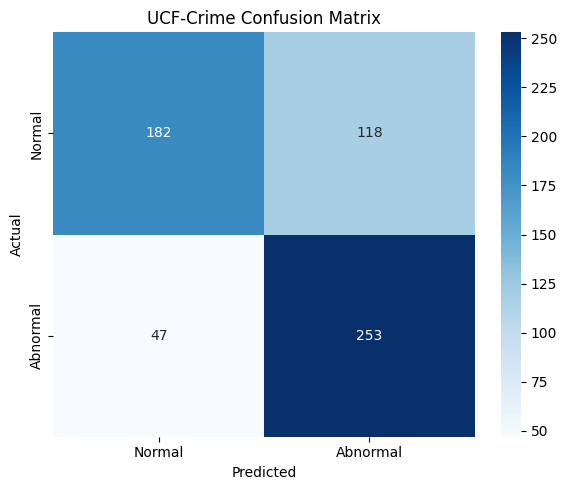

Confusion matrix saved successfully!


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("UCF-Crime Confusion Matrix")
plt.tight_layout()

plt.savefig("UCF_Crime_Confusion_Matrix.png", dpi=300)
plt.show()

print("Confusion matrix saved successfully!")

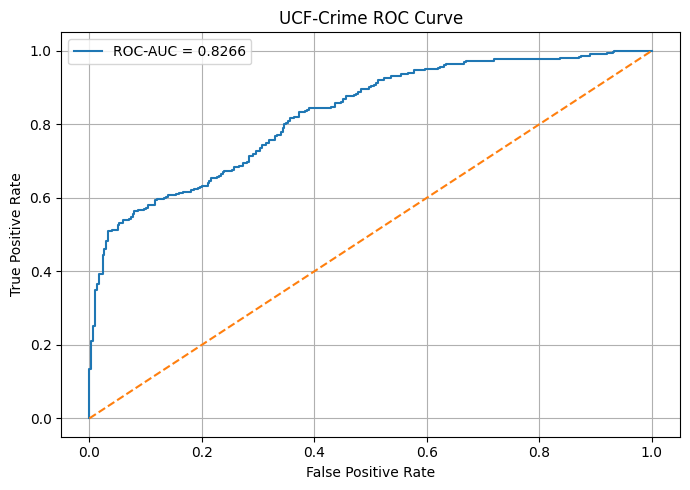

ROC-AUC: 0.8266
ROC curve saved successfully!


In [16]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("UCF-Crime ROC Curve")
plt.legend()
plt.grid()
plt.tight_layout()

plt.savefig("UCF_Crime_ROC_Curve.png", dpi=300)
plt.show()

print(f"ROC-AUC: {auc:.4f}")
print("ROC curve saved successfully!")